<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/comparesimulations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing process simulations with NeqSim

**A reproducible workflow for NeqSim, UNISIM, and DWSIM studies**

**Audience.** Process engineers, students, model-assurance specialists, and developers who
need to compare process simulators without confusing model choices with software defects.

**Prerequisites.** Basic phase equilibrium, steady-state material and energy balances,
compressor terminology, and introductory Python.

## Learning objectives

By the end, you can:

1. freeze a simulator-neutral case definition and create a traceable fingerprint;
2. build the same natural-gas conditioning train with current NeqSim process objects;
3. compare SRK and Peng–Robinson equation-of-state choices;
4. audit total mass, component molar flow, cooler energy, and compressor energy;
5. quantify sensitivity to separator temperature and pressure;
6. import UNISIM or DWSIM results through a strict, unit-labelled data contract; and
7. screen a feasible operating envelope without presenting invented external results.

> The previous catalog target was a zero-byte file. Its preservation inventory is therefore
> **zero prior examples and zero prior figures**. This notebook creates the intended
> comparison workflow while making all provenance and modelling boundaries explicit.

## 1. Reproducible Colab setup

The setup cell installs missing packages only. In a clean Colab runtime, `neqsim` comes
from the public Python Package Index and starts its bundled Java library through JPype.
The executed notebook records the actual package and runtime versions.

In [ ]:
import importlib.util
import subprocess
import sys


required_packages = {
    "neqsim": "neqsim",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *missing_packages,
        ]
    )

## 2. Imports, versions, and visual conventions

Results are stored in `pandas` tables. NumPy supports deterministic audits and design
sweeps. Matplotlib uses a colour-blind-friendly blue/orange palette. The NeqSim Java
namespace is accessed through `jneqsim`.

In [ ]:
import hashlib
import json
import platform
import subprocess
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import FancyBboxPatch
from neqsim import jneqsim


BLUE = "#0072B2"
ORANGE = "#D55E00"
GREEN = "#009E73"
PURPLE = "#CC79A7"
plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 10,
    }
)

java_version = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True,
    check=True,
).stderr.splitlines()[0]
runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            version("neqsim"),
            platform.python_version(),
            java_version,
        ],
    }
)
display(runtime_table)

,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,"openjdk version ""17.0.19"" 2026-04-21"


## 3. What a fair simulator comparison requires

Comparing software names is not enough. Every simulator must receive the same:

- component list and normalized feed composition;
- feed temperature, pressure, and flow basis;
- equation of state and binary-interaction policy;
- unit-operation specifications and efficiency definition;
- convergence status and unit system; and
- reporting basis, including absolute versus gauge pressure.

The present case is synthetic and reproducible. It is not plant data and does not claim
equivalence to a vendor regression set. External rows remain deliberately blank until a
user supplies traceable UNISIM or DWSIM exports.

## 4. Governing balances

A steady separator closes total mass:

$$
\dot{m}_{F} = \dot{m}_{G} + \dot{m}_{L}
$$

Each component $i$ also closes on a molar basis:

$$
\dot{n}_{F} z_i = \dot{n}_{G} y_i + \dot{n}_{L} x_i
$$

The valve is modelled as isenthalpic. For a steady cooler with negligible kinetic and
potential-energy changes, the signed duty is:

$$
\dot{Q} = \dot{m}\left(h_{\mathrm{out}}-h_{\mathrm{in}}\right)
$$

For an adiabatic compressor, positive shaft power is:

$$
\dot{W} = \dot{m}\left(h_{\mathrm{out}}-h_{\mathrm{in}}\right)
$$

Here $\dot{m}$ is mass flow in kg/s, $\dot{n}$ is molar flow in mol/s, $h$ is specific
enthalpy in J/kg, and duty or power is in W.

## 5. Freeze the case definition

The feed represents a moderately rich natural gas. The conditioning train throttles from
70 to 30 bara, cools to 5 °C, separates condensate, and recompresses the gas to 70 bara.
Compressor efficiency is an isentropic efficiency, not a polytropic efficiency.

In [ ]:
component_mole_fractions = {
    "nitrogen": 0.020,
    "CO2": 0.015,
    "methane": 0.800,
    "ethane": 0.080,
    "propane": 0.040,
    "i-butane": 0.015,
    "n-butane": 0.015,
    "i-pentane": 0.005,
    "n-pentane": 0.005,
    "n-hexane": 0.005,
}
case_definition = {
    "feed_temperature_c": 35.0,
    "feed_pressure_bara": 70.0,
    "feed_mass_flow_kg_s": 10.0,
    "separator_temperature_c": 5.0,
    "separator_pressure_bara": 30.0,
    "compressor_outlet_pressure_bara": 70.0,
    "compressor_isentropic_efficiency": 0.78,
    "mixing_rule": "classic",
    "composition": component_mole_fractions,
}

composition_table = pd.DataFrame(
    {
        "Component": component_mole_fractions.keys(),
        "Mole fraction [-]": component_mole_fractions.values(),
    }
)
case_table = pd.DataFrame(
    {
        "Quantity": [
            "Feed temperature",
            "Feed pressure",
            "Feed mass flow",
            "Separator temperature",
            "Separator pressure",
            "Compressor outlet pressure",
            "Compressor isentropic efficiency",
        ],
        "Value": [
            case_definition["feed_temperature_c"],
            case_definition["feed_pressure_bara"],
            case_definition["feed_mass_flow_kg_s"],
            case_definition["separator_temperature_c"],
            case_definition["separator_pressure_bara"],
            case_definition["compressor_outlet_pressure_bara"],
            case_definition["compressor_isentropic_efficiency"],
        ],
        "Unit": ["°C", "bara", "kg/s", "°C", "bara", "bara", "-"],
    }
)
display(composition_table)
display(case_table)

,Component,Mole fraction [-]
0,nitrogen,0.020
1,CO2,0.015
2,methane,0.800
3,ethane,0.080
4,propane,0.040
5,i-butane,0.015
6,n-butane,0.015
7,i-pentane,0.005
8,n-pentane,0.005
9,n-hexane,0.005


,Quantity,Value,Unit
0,Feed temperature,35.00,°C
1,Feed pressure,70.00,bara
2,Feed mass flow,10.00,kg/s
3,Separator temperature,5.00,°C
4,Separator pressure,30.00,bara
5,Compressor outlet pressure,70.00,bara
6,Compressor isentropic efficiency,0.78,-


## 6. Create a case fingerprint

A sorted JSON representation is hashed with SHA-256. The short fingerprint is not a
security control; it is a practical guard against comparing runs that silently used
different inputs.

In [ ]:
canonical_case_json = json.dumps(
    case_definition,
    sort_keys=True,
    separators=(",", ":"),
)
case_fingerprint = hashlib.sha256(
    canonical_case_json.encode("utf-8")
).hexdigest()

print(f"Case fingerprint: {case_fingerprint}")
print(f"Composition sum: {sum(component_mole_fractions.values()):.12f}")

Case fingerprint: dfc3cc50b1bd83776ee034e4ac3368d267a9ee3bd42e28802d3d019e18797c48
Composition sum: 1.000000000000


## 7. Build thermodynamic systems in NeqSim

`SystemSrkEos` and `SystemPrEos` provide Soave–Redlich–Kwong and Peng–Robinson cubic
equations of state. Both are widely used for hydrocarbon processing. This is a model-form
sensitivity: a difference does not by itself identify which simulator is correct.

The mixing rule is set after all components are added, multiphase checking is enabled, and
physical properties are initialized before reading density.

In [ ]:
def build_fluid(model_name):
    model_class = {
        "SRK": jneqsim.thermo.system.SystemSrkEos,
        "PR": jneqsim.thermo.system.SystemPrEos,
    }[model_name]
    fluid = model_class(
        case_definition["feed_temperature_c"] + 273.15,
        case_definition["feed_pressure_bara"],
    )

    for component_name, mole_fraction in component_mole_fractions.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule(case_definition["mixing_rule"])
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(
        case_definition["feed_mass_flow_kg_s"],
        "kg/sec",
    )
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(
        fluid
    )
    operations.TPflash()
    fluid.init(0)
    fluid.init(1)
    fluid.initPhysicalProperties()
    return fluid


feed_fluids = {
    model_name: build_fluid(model_name)
    for model_name in ["SRK", "PR"]
}
feed_property_table = pd.DataFrame(
    [
        {
            "Model": model_name,
            "Molar mass [kg/mol]": fluid.getMolarMass("kg/mol"),
            "Density [kg/m³]": fluid.getDensity("kg/m3"),
            "Enthalpy [kJ/kg]": fluid.getEnthalpy("J/kg") / 1000.0,
        }
        for model_name, fluid in feed_fluids.items()
    ]
)
display(feed_property_table)

,Model,Molar mass [kg/mol],Density [kg/m³],Enthalpy [kJ/kg]
0,SRK,0.02112,70.055901,17.560639
1,PR,0.02112,71.180311,1.466675


Both feed systems produce finite properties at the specified state. The process stream and
downstream unit operations perform the equilibrium calculations used for the phase split.
Small SRK–PR property differences are expected because their attractive and co-volume
terms differ. Absolute enthalpy reference levels are model dependent, so the energy audits
use inlet-to-outlet enthalpy changes within each model rather than comparing absolute feed
enthalpies across models.

## 8. Process topology

The visual below is generated from the same specifications used by the model. It shows
calculation order and the reporting points used in all comparisons.

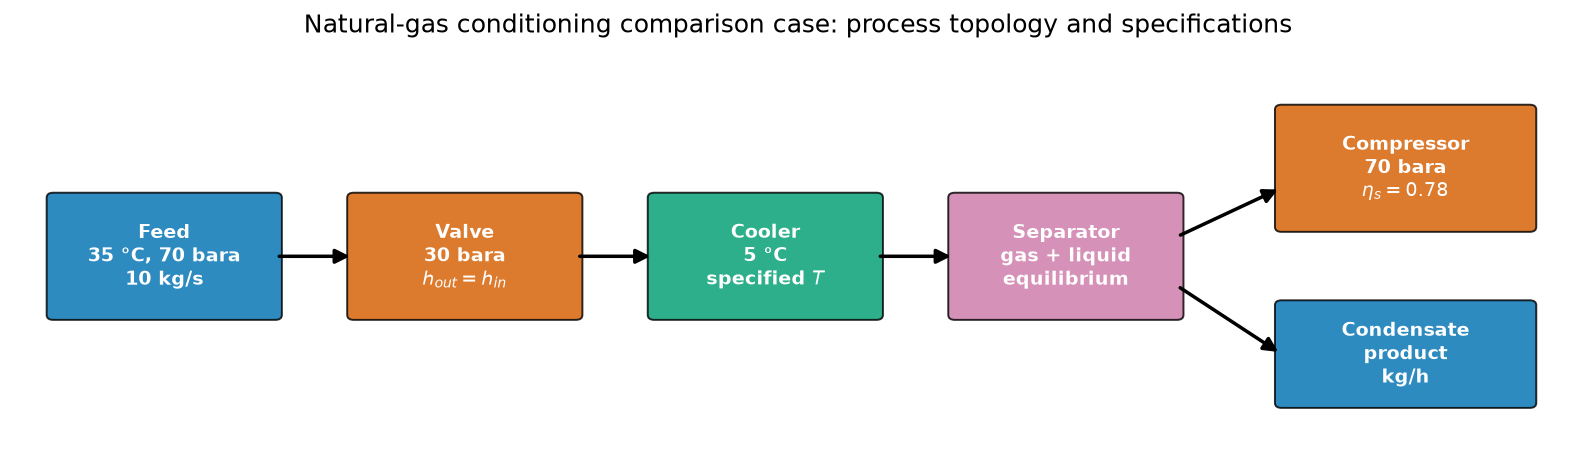

In [ ]:
figure, axis = plt.subplots(figsize=(11.5, 3.4))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

unit_boxes = [
    (0.3, 1.35, 1.7, 1.2, "Feed\n35 °C, 70 bara\n10 kg/s", BLUE),
    (2.6, 1.35, 1.7, 1.2, "Valve\n30 bara\n$h_{out}=h_{in}$", ORANGE),
    (4.9, 1.35, 1.7, 1.2, "Cooler\n5 °C\nspecified $T$", GREEN),
    (7.2, 1.35, 1.7, 1.2, "Separator\ngas + liquid\nequilibrium", PURPLE),
    (9.7, 2.25, 1.9, 1.2, "Compressor\n70 bara\n$\\eta_s=0.78$", ORANGE),
    (9.7, 0.45, 1.9, 1.0, "Condensate\nproduct\nkg/h", BLUE),
]

for x_value, y_value, width, height, label, colour in unit_boxes:
    box = FancyBboxPatch(
        (x_value, y_value),
        width,
        height,
        boxstyle="round,pad=0.05",
        facecolor=colour,
        edgecolor="black",
        alpha=0.82,
    )
    axis.add_patch(box)
    axis.text(
        x_value + width / 2.0,
        y_value + height / 2.0,
        label,
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

arrow_pairs = [
    ((2.0, 1.95), (2.6, 1.95)),
    ((4.3, 1.95), (4.9, 1.95)),
    ((6.6, 1.95), (7.2, 1.95)),
    ((8.9, 2.15), (9.7, 2.65)),
    ((8.9, 1.65), (9.7, 0.95)),
]

for start_point, end_point in arrow_pairs:
    axis.add_patch(
        FancyArrowPatch(
            start_point,
            end_point,
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.8,
            color="black",
        )
    )

axis.set_title(
    "Natural-gas conditioning comparison case: process topology and specifications",
    fontsize=13,
    pad=12,
)
plt.tight_layout()
plt.show()

## 9. Assemble and solve the NeqSim flowsheet

`Stream` carries the thermodynamic system and flow basis. `ThrottlingValve` performs an
isenthalpic pressure reduction. `Cooler` imposes the separator temperature. `Separator`
exposes equilibrium gas and liquid outlets. `Compressor` raises only the gas pressure.
`ProcessSystem.run()` solves units in dependency order.

The function returns both a compact result record and the live objects needed for audits.
This makes the workflow reusable for model and operating-condition sweeps.

In [ ]:
Stream = jneqsim.process.equipment.stream.Stream
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def run_process_case(
    model_name,
    separator_temperature_c=None,
    separator_pressure_bara=None,
):
    if separator_temperature_c is None:
        separator_temperature_c = case_definition[
            "separator_temperature_c"
        ]

    if separator_pressure_bara is None:
        separator_pressure_bara = case_definition[
            "separator_pressure_bara"
        ]

    feed = Stream(f"{model_name} feed", build_fluid(model_name))
    valve = ThrottlingValve(f"{model_name} inlet valve", feed)
    valve.setOutletPressure(separator_pressure_bara, "bara")
    valve.setPercentValveOpening(100.0)

    cooler = Cooler(f"{model_name} feed cooler", valve.getOutletStream())
    cooler.setOutTemperature(separator_temperature_c, "C")

    separator = Separator(
        f"{model_name} cold separator",
        cooler.getOutletStream(),
    )
    compressor = Compressor(
        f"{model_name} gas compressor",
        separator.getGasOutStream(),
    )
    compressor.setOutletPressure(
        case_definition["compressor_outlet_pressure_bara"],
        "bara",
    )
    compressor.setIsentropicEfficiency(
        case_definition["compressor_isentropic_efficiency"]
    )

    process = ProcessSystem()

    for unit_operation in [
        feed,
        valve,
        cooler,
        separator,
        compressor,
    ]:
        process.add(unit_operation)

    process.run()

    gas_product = separator.getGasOutStream()
    liquid_product = separator.getLiquidOutStream()
    cooler_inlet = valve.getOutletStream()
    cooler_outlet = cooler.getOutletStream()
    compressor_outlet = compressor.getOutletStream()
    cooler_enthalpy_change_w = cooler_outlet.getFlowRate("kg/sec") * (
        cooler_outlet.getFluid().getEnthalpy("J/kg")
        - cooler_inlet.getFluid().getEnthalpy("J/kg")
    )
    compressor_enthalpy_change_w = compressor_outlet.getFlowRate(
        "kg/sec"
    ) * (
        compressor_outlet.getFluid().getEnthalpy("J/kg")
        - gas_product.getFluid().getEnthalpy("J/kg")
    )
    result = {
        "Model": model_name,
        "Separator temperature [°C]": separator_temperature_c,
        "Separator pressure [bara]": separator_pressure_bara,
        "Feed flow [kg/h]": feed.getFlowRate("kg/hr"),
        "Gas flow [kg/h]": gas_product.getFlowRate("kg/hr"),
        "Liquid flow [kg/h]": liquid_product.getFlowRate("kg/hr"),
        "Liquid recovery [wt%]": (
            100.0
            * liquid_product.getFlowRate("kg/hr")
            / feed.getFlowRate("kg/hr")
        ),
        "Cooling load [kW]": -cooler.getDuty() / 1000.0,
        "Compressor power [kW]": compressor.getPower("W") / 1000.0,
        "Compressor outlet [°C]": (
            compressor.getOutletStream().getTemperature("C")
        ),
        "Gas density [kg/m³]": gas_product.getFluid().getDensity("kg/m3"),
        "Liquid density [kg/m³]": (
            liquid_product.getFluid().getDensity("kg/m3")
        ),
        "Mass residual [kg/h]": (
            feed.getFlowRate("kg/hr")
            - gas_product.getFlowRate("kg/hr")
            - liquid_product.getFlowRate("kg/hr")
        ),
        "Cooler energy residual [W]": (
            cooler.getDuty() - cooler_enthalpy_change_w
        ),
        "Compressor energy residual [W]": (
            compressor.getPower("W")
            - compressor_enthalpy_change_w
        ),
    }
    objects = {
        "process": process,
        "feed": feed,
        "valve": valve,
        "cooler": cooler,
        "separator": separator,
        "gas product": gas_product,
        "liquid product": liquid_product,
        "compressor": compressor,
    }
    return {
        "result": result,
        "objects": objects,
    }

## 10. Run the base case with both equations of state

Each model uses identical equipment specifications and flow basis. The base table retains
full precision for audit calculations; formatting is applied only for display.

In [ ]:
base_cases = {
    model_name: run_process_case(model_name)
    for model_name in ["SRK", "PR"]
}
base_results = pd.DataFrame(
    [
        base_cases[model_name]["result"]
        for model_name in ["SRK", "PR"]
    ]
)
displayed_base_results = base_results[
    [
        "Model",
        "Gas flow [kg/h]",
        "Liquid flow [kg/h]",
        "Liquid recovery [wt%]",
        "Cooling load [kW]",
        "Compressor power [kW]",
        "Compressor outlet [°C]",
    ]
].copy()

display(displayed_base_results.round(6))

,Model,Gas flow [kg/h],Liquid flow [kg/h],Liquid recovery [wt%],Cooling load [kW],Compressor power [kW],Compressor outlet [°C]
0,SRK,33823.635786,2176.364214,6.045456,341.001654,1145.927880,74.846249
1,PR,33938.682557,2061.317443,5.725882,303.328679,1117.512416,74.679011


The cubic models predict similar gas conditioning, but the liquid rate and utilities do
not coincide. That spread is a useful early warning: a cross-simulator comparison must
align property packages and interaction parameters before blaming implementation.

## 11. Total and component balance audit

Total mass can close while component errors cancel. Component molar rates are therefore
reconstructed from each stream's molar flow and overall composition.

In [ ]:
component_names = list(component_mole_fractions)


def component_molar_rates(stream_object):
    stream_fluid = stream_object.getFluid()
    total_molar_rate = stream_object.getFlowRate("mole/sec")
    return np.asarray(
        [
            total_molar_rate
            * stream_fluid.getComponent(component_name).getz()
            for component_name in component_names
        ]
    )


audit_rows = []
component_balance_tables = {}

for model_name, case in base_cases.items():
    objects = case["objects"]
    feed_rates = component_molar_rates(objects["feed"])
    gas_rates = component_molar_rates(objects["gas product"])
    liquid_rates = component_molar_rates(objects["liquid product"])
    component_residuals = feed_rates - gas_rates - liquid_rates
    component_balance_tables[model_name] = pd.DataFrame(
        {
            "Component": component_names,
            "Feed [mol/s]": feed_rates,
            "Gas [mol/s]": gas_rates,
            "Liquid [mol/s]": liquid_rates,
            "Residual [mol/s]": component_residuals,
        }
    )
    audit_rows.append(
        {
            "Model": model_name,
            "Mass residual [kg/h]": case["result"][
                "Mass residual [kg/h]"
            ],
            "Maximum component residual [mol/s]": np.max(
                np.abs(component_residuals)
            ),
            "Cooler energy residual [W]": case["result"][
                "Cooler energy residual [W]"
            ],
            "Compressor energy residual [W]": case["result"][
                "Compressor energy residual [W]"
            ],
        }
    )

audit_table = pd.DataFrame(audit_rows)
display(component_balance_tables["SRK"])
display(audit_table)

,Component,Feed [mol/s],Gas [mol/s],Liquid [mol/s],Residual [mol/s]
0,nitrogen,9.469527,9.456157,0.013369,-1.332268e-15
1,CO2,7.102145,7.023706,0.078439,7.494005e-16
2,methane,378.781064,377.111757,1.669307,-1.820766e-14
3,ethane,37.878106,36.955657,0.922450,-9.769963e-15
4,propane,18.939053,17.420182,1.518871,-7.771561e-15
5,i-butane,7.102145,5.877134,1.225011,-1.998401e-15
6,n-butane,7.102145,5.460360,1.641785,-3.330669e-15
7,i-pentane,2.367382,1.361226,1.006156,-2.442491e-15
8,n-pentane,2.367382,1.193794,1.173588,-3.330669e-15
9,n-hexane,2.367382,0.564972,1.802410,-4.662937e-15


,Model,Mass residual [kg/h],Maximum component residual [mol/s],Cooler energy residual [W],Compressor energy residual [W]
0,SRK,-2.091838e-11,1.820766e-14,5.820766e-11,2.328306e-10
1,PR,-3.228706e-11,1.403322e-13,5.820766e-11,0.000000e+00


Residuals are reported rather than rounded away. The energy checks compare NeqSim's signed
equipment duty or power with independently reconstructed stream-enthalpy changes.

## 12. Visual comparison of principal results

Liquid recovery and compressor power are plotted on separate axes because they have
different units and engineering meanings.

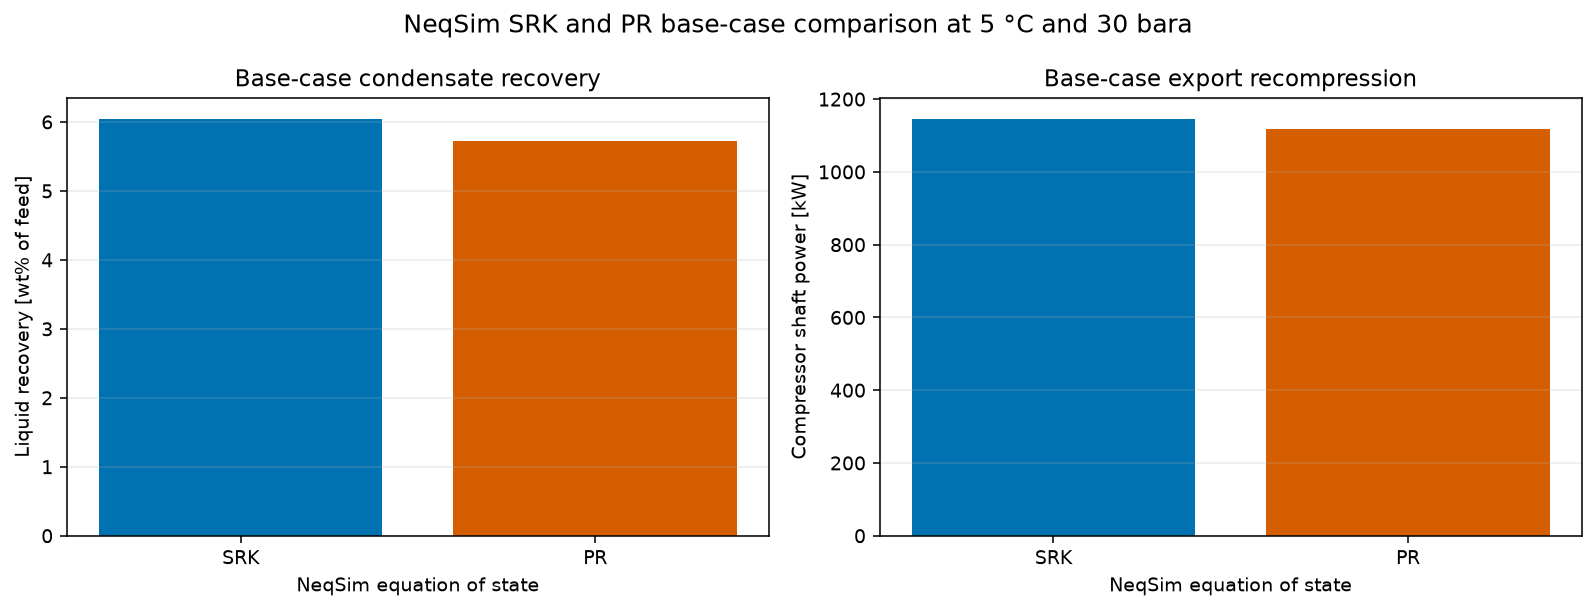

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
model_labels = base_results["Model"].tolist()
colours = [BLUE, ORANGE]

axes[0].bar(
    model_labels,
    base_results["Liquid recovery [wt%]"],
    color=colours,
)
axes[0].set_ylabel("Liquid recovery [wt% of feed]")
axes[0].set_title("Base-case condensate recovery")

axes[1].bar(
    model_labels,
    base_results["Compressor power [kW]"],
    color=colours,
)
axes[1].set_ylabel("Compressor shaft power [kW]")
axes[1].set_title("Base-case export recompression")

for axis in axes:
    axis.set_xlabel("NeqSim equation of state")
    axis.grid(axis="x", visible=False)

figure.suptitle(
    "NeqSim SRK and PR base-case comparison at 5 °C and 30 bara",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## 13. Quantify model-form spread

For a positive quantity $X$, the symmetric percentage spread is:

$$
S_X = 100\frac{X_{\max}-X_{\min}}{\left(X_{\max}+X_{\min}\right)/2}
$$

This describes disagreement; it is not uncertainty unless the model set and calibration
evidence justify that interpretation.

In [ ]:
spread_quantities = [
    "Liquid flow [kg/h]",
    "Cooling load [kW]",
    "Compressor power [kW]",
    "Gas density [kg/m³]",
    "Liquid density [kg/m³]",
]
spread_rows = []

for quantity in spread_quantities:
    values = base_results[quantity].to_numpy(dtype=float)
    symmetric_spread_percent = (
        100.0
        * (np.max(values) - np.min(values))
        / np.mean(values)
    )
    spread_rows.append(
        {
            "Quantity": quantity,
            "SRK": values[0],
            "PR": values[1],
            "Symmetric spread [%]": symmetric_spread_percent,
        }
    )

model_spread_table = pd.DataFrame(spread_rows)
display(model_spread_table.round(6))

,Quantity,SRK,PR,Symmetric spread [%]
0,Liquid flow [kg/h],2176.364214,2061.317443,5.429703
1,Cooling load [kW],341.001654,303.328679,11.693683
2,Compressor power [kW],1145.927880,1117.512416,2.510821
3,Gas density [kg/m³],29.508695,29.892393,1.291890
4,Liquid density [kg/m³],577.240184,565.549651,2.045964


The liquid-flow spread is normally larger than the gas-flow spread because phase split is
sensitive to the heavy-component fugacity calculation. Utility differences combine the
phase split with enthalpy predictions.

## 14. Separator-temperature sensitivity

Temperature is varied from −10 to 20 °C while pressure remains 30 bara. Each point rebuilds
and reruns the complete NeqSim process; no result is interpolated.

In [ ]:
temperature_values_c = np.arange(-10.0, 20.1, 5.0)
temperature_rows = []

for model_name in ["SRK", "PR"]:
    for temperature_c in temperature_values_c:
        case = run_process_case(
            model_name,
            separator_temperature_c=float(temperature_c),
        )
        temperature_rows.append(case["result"])

temperature_sensitivity = pd.DataFrame(temperature_rows)
display(
    temperature_sensitivity[
        [
            "Model",
            "Separator temperature [°C]",
            "Liquid recovery [wt%]",
            "Compressor power [kW]",
            "Cooling load [kW]",
        ]
    ].round(6)
)

,Model,Separator temperature [°C],Liquid recovery [wt%],Compressor power [kW],Cooling load [kW]
0,SRK,-10.0,11.544936,1044.845206,848.915855
1,SRK,-5.0,9.643901,1079.079899,676.672542
2,SRK,0.0,7.805409,1112.782018,507.246684
3,SRK,5.0,6.045456,1145.927880,341.001654
4,SRK,10.0,4.372714,1178.506150,178.068853
5,SRK,15.0,2.782489,1210.535117,18.177450
6,SRK,20.0,1.252073,1242.076520,-139.467985
7,PR,-10.0,11.258226,1017.554352,807.269058
8,PR,-5.0,9.343390,1051.408557,636.369271
9,PR,0.0,7.494320,1084.733475,468.281099


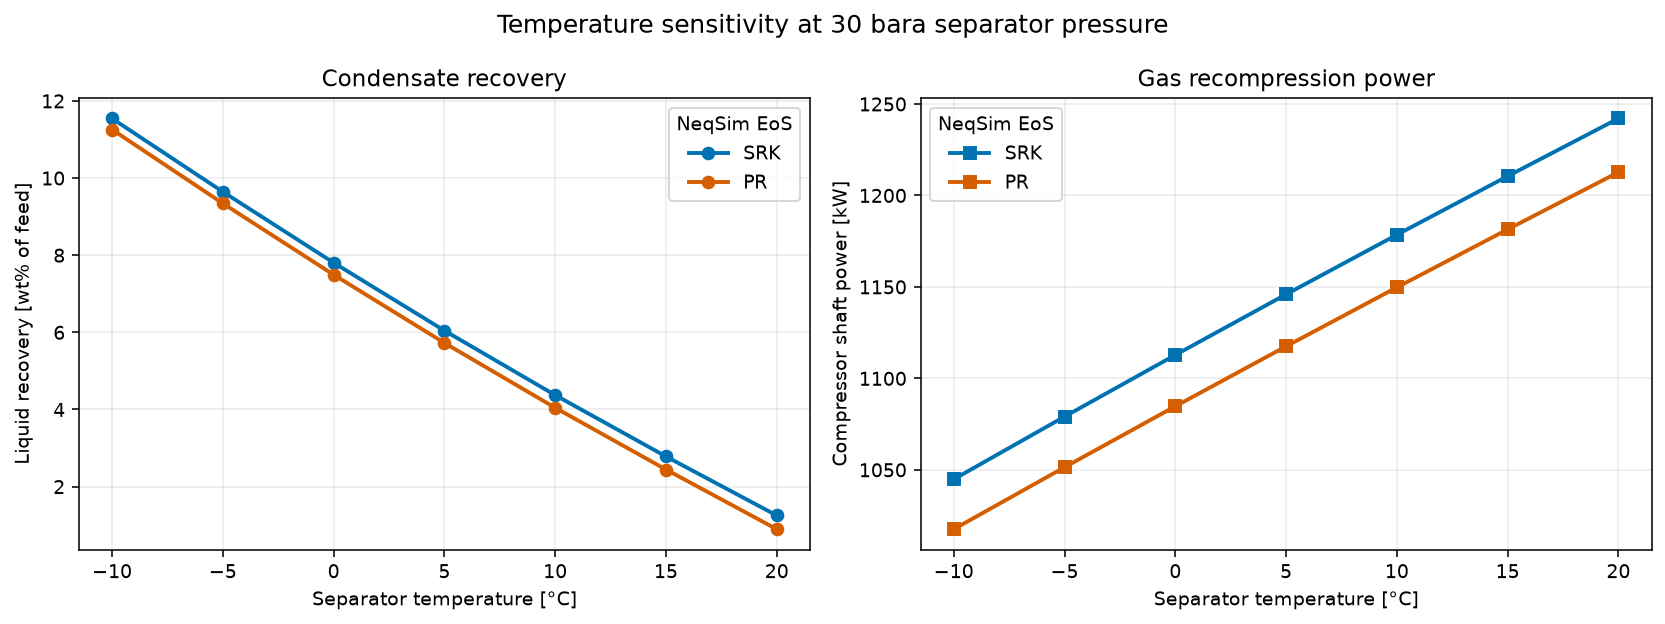

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.5))
colour_map = {
    "SRK": BLUE,
    "PR": ORANGE,
}

for model_name in ["SRK", "PR"]:
    model_data = temperature_sensitivity[
        temperature_sensitivity["Model"] == model_name
    ]
    axes[0].plot(
        model_data["Separator temperature [°C]"],
        model_data["Liquid recovery [wt%]"],
        marker="o",
        linewidth=2.0,
        label=model_name,
        color=colour_map[model_name],
    )
    axes[1].plot(
        model_data["Separator temperature [°C]"],
        model_data["Compressor power [kW]"],
        marker="s",
        linewidth=2.0,
        label=model_name,
        color=colour_map[model_name],
    )

axes[0].set_ylabel("Liquid recovery [wt% of feed]")
axes[0].set_title("Condensate recovery")
axes[1].set_ylabel("Compressor shaft power [kW]")
axes[1].set_title("Gas recompression power")

for axis in axes:
    axis.set_xlabel("Separator temperature [°C]")
    axis.legend(title="NeqSim EoS")

figure.suptitle(
    "Temperature sensitivity at 30 bara separator pressure",
    fontsize=13,
)
plt.tight_layout()
plt.show()

Cooling increases liquid recovery because more heavy hydrocarbons enter the liquid phase.
Compressor power also changes because both gas flow and inlet properties change.

## 15. Separator-pressure sensitivity

Pressure is varied from 20 to 45 bara at 5 °C. The compressor always discharges at 70
bara, so increasing separator pressure reduces its pressure ratio.

In [ ]:
pressure_values_bara = np.arange(20.0, 45.1, 5.0)
pressure_rows = []

for model_name in ["SRK", "PR"]:
    for pressure_bara in pressure_values_bara:
        case = run_process_case(
            model_name,
            separator_pressure_bara=float(pressure_bara),
        )
        pressure_rows.append(case["result"])

pressure_sensitivity = pd.DataFrame(pressure_rows)
display(
    pressure_sensitivity[
        [
            "Model",
            "Separator pressure [bara]",
            "Liquid recovery [wt%]",
            "Compressor power [kW]",
            "Compressor outlet [°C]",
        ]
    ].round(6)
)

,Model,Separator pressure [bara],Liquid recovery [wt%],Compressor power [kW],Compressor outlet [°C]
0,SRK,20.0,3.632988,1846.004365,108.347794
1,SRK,25.0,4.938556,1450.831608,89.975352
2,SRK,30.0,6.045456,1145.927880,74.846249
3,SRK,35.0,6.985890,901.995601,61.988518
4,SRK,40.0,7.781777,701.897351,50.825115
5,SRK,45.0,8.448720,534.772659,40.985855
6,PR,20.0,3.374646,1809.532808,108.182360
7,PR,25.0,4.653595,1418.423011,89.808452
8,PR,30.0,5.725882,1117.512416,74.679011
9,PR,35.0,6.625338,877.487023,61.824201


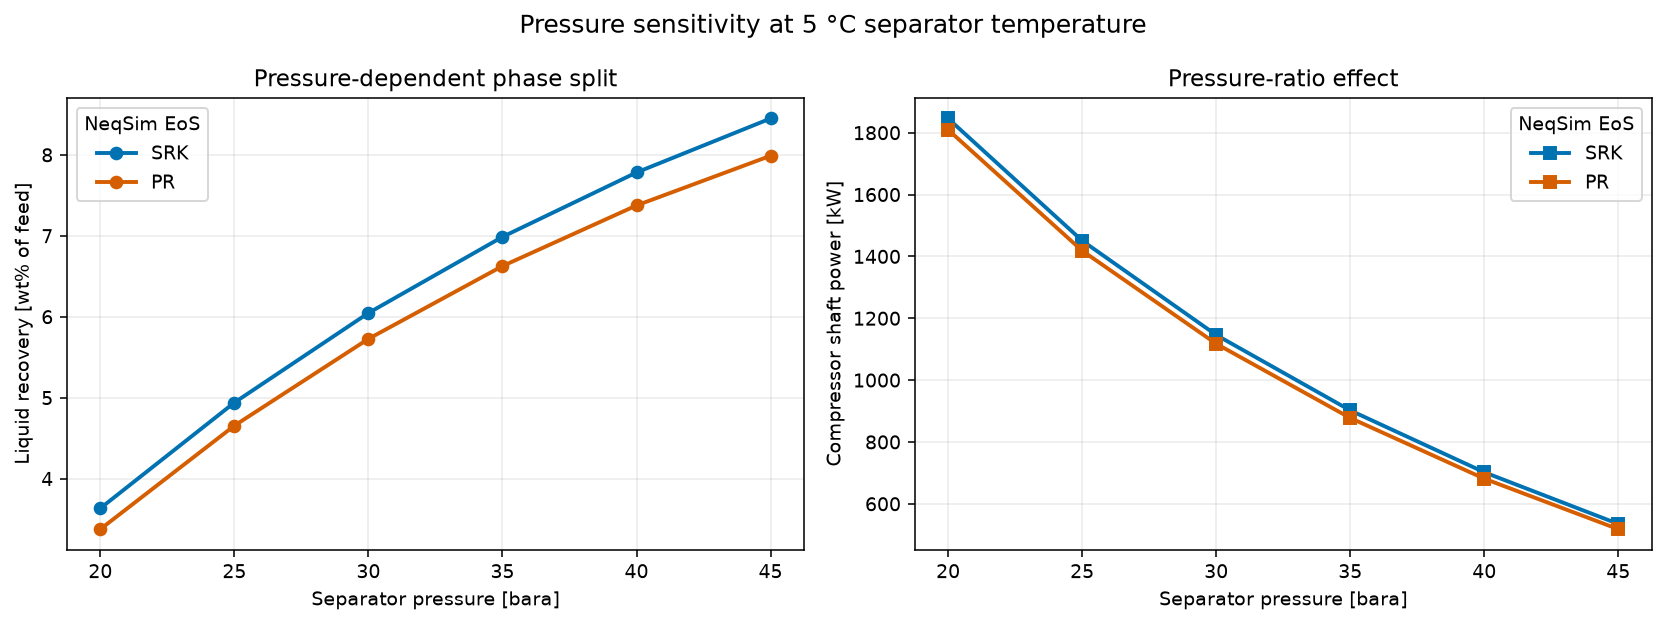

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.5))

for model_name in ["SRK", "PR"]:
    model_data = pressure_sensitivity[
        pressure_sensitivity["Model"] == model_name
    ]
    axes[0].plot(
        model_data["Separator pressure [bara]"],
        model_data["Liquid recovery [wt%]"],
        marker="o",
        linewidth=2.0,
        label=model_name,
        color=colour_map[model_name],
    )
    axes[1].plot(
        model_data["Separator pressure [bara]"],
        model_data["Compressor power [kW]"],
        marker="s",
        linewidth=2.0,
        label=model_name,
        color=colour_map[model_name],
    )

axes[0].set_ylabel("Liquid recovery [wt% of feed]")
axes[0].set_title("Pressure-dependent phase split")
axes[1].set_ylabel("Compressor shaft power [kW]")
axes[1].set_title("Pressure-ratio effect")

for axis in axes:
    axis.set_xlabel("Separator pressure [bara]")
    axis.legend(title="NeqSim EoS")

figure.suptitle(
    "Pressure sensitivity at 5 °C separator temperature",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## 16. Independent ideal-gas compressor screen

An ideal-gas estimate provides an order-of-magnitude check, not a substitute for the
real-gas calculation:

$$
\dot{W}_{\mathrm{ideal}} =
\frac{\dot{m}}{\eta_s}
\frac{k}{k-1}R_sT_1
\left[
\left(\frac{P_2}{P_1}\right)^{(k-1)/k}-1
\right]
$$

Here $R_s=R/M$ is the mixture-specific gas constant in J/(kg K), $M$ is molar mass in
kg/mol, $k=C_p/C_v$, and $\eta_s$ is isentropic efficiency. NeqSim supplies the inlet
gas composition, molar mass, and heat-capacity ratio.

In [ ]:
universal_gas_constant_j_mol_k = 8.314462618
ideal_check_rows = []

for model_name, case in base_cases.items():
    gas_product = case["objects"]["gas product"]
    gas_fluid = gas_product.getFluid()
    gas_flow_kg_s = gas_product.getFlowRate("kg/sec")
    gas_molar_mass_kg_mol = gas_fluid.getMolarMass("kg/mol")
    heat_capacity_ratio = gas_fluid.getGamma()
    gas_constant_j_kg_k = (
        universal_gas_constant_j_mol_k
        / gas_molar_mass_kg_mol
    )
    pressure_ratio = (
        case_definition["compressor_outlet_pressure_bara"]
        / case_definition["separator_pressure_bara"]
    )
    ideal_specific_work_j_kg = (
        heat_capacity_ratio
        / (heat_capacity_ratio - 1.0)
        * gas_constant_j_kg_k
        * gas_fluid.getTemperature("K")
        * (
            pressure_ratio
            ** (
                (heat_capacity_ratio - 1.0)
                / heat_capacity_ratio
            )
            - 1.0
        )
        / case_definition["compressor_isentropic_efficiency"]
    )
    ideal_power_kw = (
        gas_flow_kg_s
        * ideal_specific_work_j_kg
        / 1000.0
    )
    neqsim_power_kw = case["result"]["Compressor power [kW]"]
    ideal_check_rows.append(
        {
            "Model": model_name,
            "NeqSim real-gas power [kW]": neqsim_power_kw,
            "Ideal-gas screen [kW]": ideal_power_kw,
            "Difference from ideal screen [%]": (
                100.0
                * (neqsim_power_kw - ideal_power_kw)
                / ideal_power_kw
            ),
        }
    )

ideal_compressor_check = pd.DataFrame(ideal_check_rows)
display(ideal_compressor_check.round(6))

,Model,NeqSim real-gas power [kW],Ideal-gas screen [kW],Difference from ideal screen [%]
0,SRK,1145.927880,1324.445329,-13.478657
1,PR,1117.512416,1327.102056,-15.793031


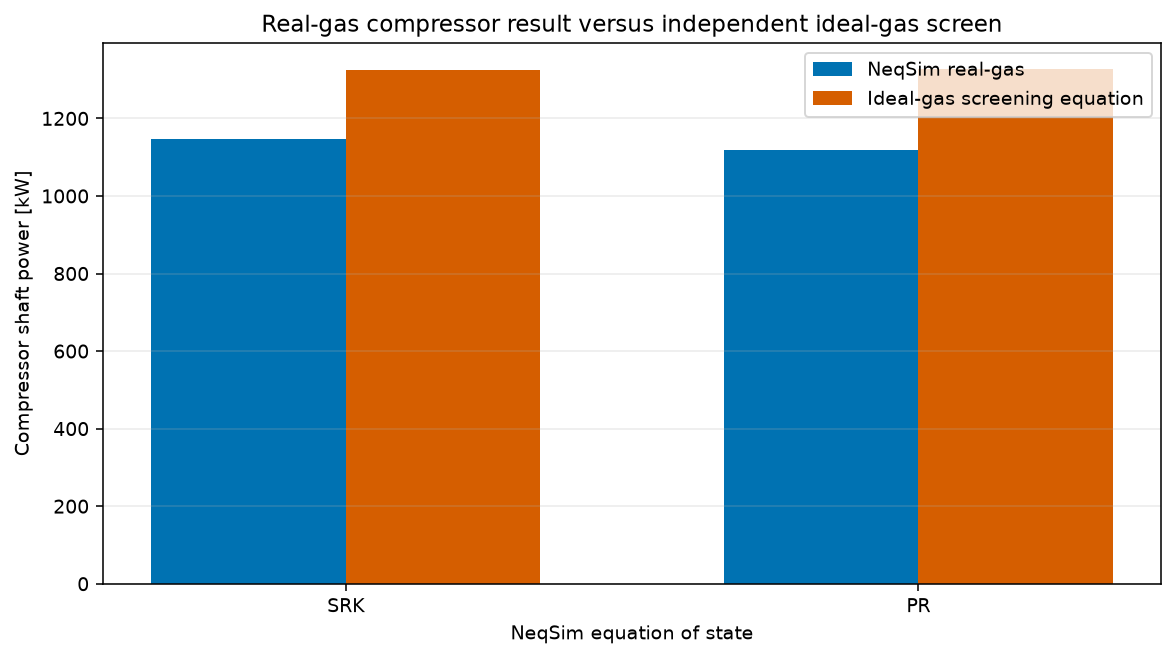

In [ ]:
x_positions = np.arange(len(ideal_compressor_check))
bar_width = 0.34
figure, axis = plt.subplots(figsize=(8.5, 4.8))
axis.bar(
    x_positions - bar_width / 2.0,
    ideal_compressor_check["NeqSim real-gas power [kW]"],
    width=bar_width,
    label="NeqSim real-gas",
    color=BLUE,
)
axis.bar(
    x_positions + bar_width / 2.0,
    ideal_compressor_check["Ideal-gas screen [kW]"],
    width=bar_width,
    label="Ideal-gas screening equation",
    color=ORANGE,
)
axis.set_xticks(x_positions, ideal_compressor_check["Model"])
axis.set_xlabel("NeqSim equation of state")
axis.set_ylabel("Compressor shaft power [kW]")
axis.set_title(
    "Real-gas compressor result versus independent ideal-gas screen"
)
axis.legend()
axis.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Agreement within engineering order of magnitude supports the unit basis. A difference is
expected because the ideal equation holds $k$ constant and omits residual enthalpy.

## 17. A strict UNISIM and DWSIM result contract

The notebook does **not** invent vendor outputs. Instead, it creates unit-labelled rows for
NeqSim and blank templates for UNISIM and DWSIM. Replace only the blank numerical fields
with values exported from runs that use the fingerprinted case.

The `Status` field prevents missing data from being mistaken for a zero result.

In [ ]:
comparison_columns = [
    "Simulator",
    "Simulator version",
    "Property package",
    "Case fingerprint",
    "Gas flow [kg/h]",
    "Liquid flow [kg/h]",
    "Cooling load [kW]",
    "Compressor power [kW]",
    "Compressor outlet [°C]",
    "Status",
]
comparison_rows = []

for _, result_row in base_results.iterrows():
    comparison_rows.append(
        {
            "Simulator": f"NeqSim-{result_row['Model']}",
            "Simulator version": version("neqsim"),
            "Property package": result_row["Model"],
            "Case fingerprint": case_fingerprint,
            "Gas flow [kg/h]": result_row["Gas flow [kg/h]"],
            "Liquid flow [kg/h]": result_row["Liquid flow [kg/h]"],
            "Cooling load [kW]": result_row["Cooling load [kW]"],
            "Compressor power [kW]": result_row[
                "Compressor power [kW]"
            ],
            "Compressor outlet [°C]": result_row[
                "Compressor outlet [°C]"
            ],
            "Status": "supplied",
        }
    )

for simulator_name in ["UNISIM", "DWSIM"]:
    comparison_rows.append(
        {
            "Simulator": simulator_name,
            "Simulator version": "enter exported version",
            "Property package": "enter configured package",
            "Case fingerprint": case_fingerprint,
            "Gas flow [kg/h]": np.nan,
            "Liquid flow [kg/h]": np.nan,
            "Cooling load [kW]": np.nan,
            "Compressor power [kW]": np.nan,
            "Compressor outlet [°C]": np.nan,
            "Status": "not supplied",
        }
    )

simulator_comparison_template = pd.DataFrame(
    comparison_rows,
    columns=comparison_columns,
)
display(simulator_comparison_template)

,Simulator,Simulator version,Property package,Case fingerprint,Gas flow [kg/h],Liquid flow [kg/h],Cooling load [kW],Compressor power [kW],Compressor outlet [°C],Status
0,NeqSim-SRK,3.16.0,SRK,dfc3cc50b1bd83776ee034e4ac3368d267a9ee3bd42e28...,33823.635786,2176.364214,341.001654,1145.927880,74.846249,supplied
1,NeqSim-PR,3.16.0,PR,dfc3cc50b1bd83776ee034e4ac3368d267a9ee3bd42e28...,33938.682557,2061.317443,303.328679,1117.512416,74.679011,supplied
2,UNISIM,enter exported version,enter configured package,dfc3cc50b1bd83776ee034e4ac3368d267a9ee3bd42e28...,NaN,NaN,NaN,NaN,NaN,not supplied
3,DWSIM,enter exported version,enter configured package,dfc3cc50b1bd83776ee034e4ac3368d267a9ee3bd42e28...,NaN,NaN,NaN,NaN,NaN,not supplied


## 18. Validate and compare supplied simulator rows

The validator rejects missing columns, inconsistent fingerprints, and non-finite values in
rows marked `supplied`. Relative deviations use NeqSim-SRK as the explicit baseline:

$$
\delta_X = 100\frac{X-X_{\mathrm{baseline}}}{X_{\mathrm{baseline}}}
$$

A tolerance must come from the engineering purpose, numerical settings, and validated
model uncertainty. No universal pass/fail percentage is assumed here.

In [ ]:
numeric_comparison_columns = [
    "Gas flow [kg/h]",
    "Liquid flow [kg/h]",
    "Cooling load [kW]",
    "Compressor power [kW]",
    "Compressor outlet [°C]",
]


def validate_comparison_table(comparison_table):
    missing_columns = set(comparison_columns) - set(
        comparison_table.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing comparison columns: {sorted(missing_columns)}"
        )

    fingerprints = comparison_table["Case fingerprint"].dropna().unique()

    if len(fingerprints) != 1 or fingerprints[0] != case_fingerprint:
        raise ValueError("Every row must use the current case fingerprint.")

    supplied_rows = comparison_table[
        comparison_table["Status"] == "supplied"
    ]
    supplied_values = supplied_rows[
        numeric_comparison_columns
    ].to_numpy(dtype=float)

    if not np.isfinite(supplied_values).all():
        raise ValueError(
            "Rows marked supplied must contain finite numerical results."
        )

    return supplied_rows


def calculate_deviations(comparison_table, baseline_name="NeqSim-SRK"):
    supplied_rows = validate_comparison_table(comparison_table)
    baseline_rows = supplied_rows[
        supplied_rows["Simulator"] == baseline_name
    ]

    if len(baseline_rows) != 1:
        raise ValueError("The baseline simulator row must appear exactly once.")

    baseline = baseline_rows.iloc[0]
    deviation_table = supplied_rows[
        ["Simulator", "Property package"]
    ].copy()

    for quantity in numeric_comparison_columns:
        deviation_table[f"{quantity} deviation [%]"] = (
            100.0
            * (supplied_rows[quantity] - baseline[quantity])
            / baseline[quantity]
        )

    return deviation_table


available_deviations = calculate_deviations(
    simulator_comparison_template
)
display(available_deviations.round(6))

,Simulator,Property package,Gas flow [kg/h] deviation [%],Liquid flow [kg/h] deviation [%],Cooling load [kW] deviation [%],Compressor power [kW] deviation [%],Compressor outlet [°C] deviation [%]
0,NeqSim-SRK,SRK,0.000000,0.000000,0.00000,0.00000,0.000000
1,NeqSim-PR,PR,0.340137,-5.286191,-11.04774,-2.47969,-0.223442


Only the two executed NeqSim rows are compared now. After traceable external rows are
supplied and their status changed, the same function will include them automatically.

## 19. Practical application: operating-envelope screening

The final application evaluates a complete SRK process grid. A case is feasible when:

- liquid recovery is at least 5 wt% of feed;
- compressor outlet temperature is below 90 °C; and
- cooling load is non-negative.

The feasible point with the lowest compressor power is selected. These limits are
illustrative screening constraints, not equipment design guarantees.

In [ ]:
design_temperatures_c = [-10.0, 0.0, 5.0, 10.0, 20.0]
design_pressures_bara = [20.0, 25.0, 30.0, 35.0, 40.0, 45.0]
design_rows = []

for temperature_c in design_temperatures_c:
    for pressure_bara in design_pressures_bara:
        case = run_process_case(
            "SRK",
            separator_temperature_c=temperature_c,
            separator_pressure_bara=pressure_bara,
        )
        design_rows.append(case["result"])

design_envelope = pd.DataFrame(design_rows)
design_envelope["Feasible"] = (
    (design_envelope["Liquid recovery [wt%]"] >= 5.0)
    & (design_envelope["Compressor outlet [°C]"] < 90.0)
    & (design_envelope["Cooling load [kW]"] >= 0.0)
)
feasible_designs = design_envelope[design_envelope["Feasible"]].copy()
selected_design = feasible_designs.sort_values(
    "Compressor power [kW]"
).iloc[0]

display(
    selected_design[
        [
            "Separator temperature [°C]",
            "Separator pressure [bara]",
            "Liquid recovery [wt%]",
            "Cooling load [kW]",
            "Compressor power [kW]",
            "Compressor outlet [°C]",
        ]
    ].to_frame("Selected value")
)

,Selected value
Separator temperature [°C],-10.0
Separator pressure [bara],45.0
Liquid recovery [wt%],14.563951
Cooling load [kW],1151.642609
Compressor power [kW],477.796105
Compressor outlet [°C],25.373448


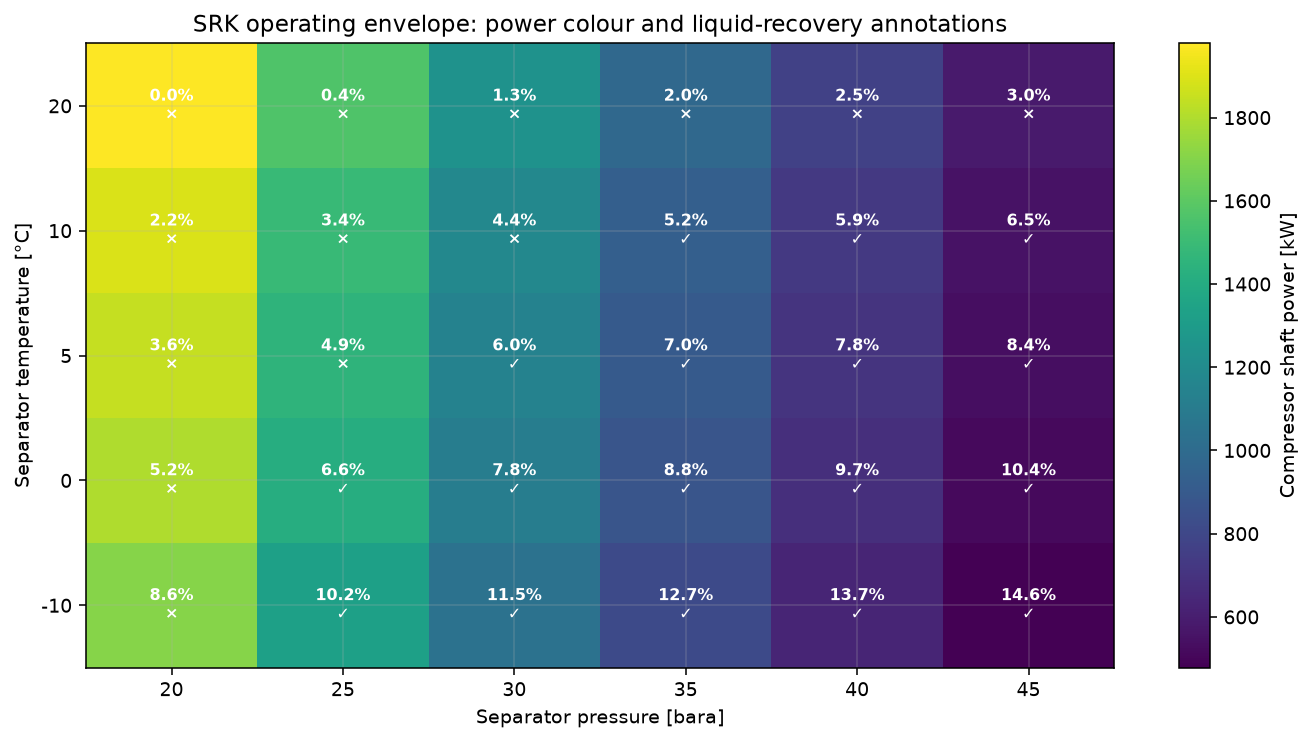

In [ ]:
power_grid = design_envelope.pivot(
    index="Separator temperature [°C]",
    columns="Separator pressure [bara]",
    values="Compressor power [kW]",
)
recovery_grid = design_envelope.pivot(
    index="Separator temperature [°C]",
    columns="Separator pressure [bara]",
    values="Liquid recovery [wt%]",
)
feasible_grid = design_envelope.pivot(
    index="Separator temperature [°C]",
    columns="Separator pressure [bara]",
    values="Feasible",
)

figure, axis = plt.subplots(figsize=(10.0, 5.4))
image = axis.imshow(
    power_grid.to_numpy(),
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
colour_bar = figure.colorbar(image, ax=axis)
colour_bar.set_label("Compressor shaft power [kW]")
axis.set_xticks(
    np.arange(len(power_grid.columns)),
    [f"{value:.0f}" for value in power_grid.columns],
)
axis.set_yticks(
    np.arange(len(power_grid.index)),
    [f"{value:.0f}" for value in power_grid.index],
)
axis.set_xlabel("Separator pressure [bara]")
axis.set_ylabel("Separator temperature [°C]")
axis.set_title(
    "SRK operating envelope: power colour and liquid-recovery annotations"
)

for row_index in range(len(power_grid.index)):
    for column_index in range(len(power_grid.columns)):
        recovery_value = recovery_grid.iloc[row_index, column_index]
        feasible_value = feasible_grid.iloc[row_index, column_index]
        marker = "✓" if feasible_value else "×"
        axis.text(
            column_index,
            row_index,
            f"{recovery_value:.1f}%\n{marker}",
            ha="center",
            va="center",
            color="white",
            fontsize=8,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

Each annotation shows liquid recovery and a feasible check mark or infeasible cross. The
selected point minimizes compressor power only within the tested grid and constraints; it
does not account for refrigeration cost, equipment size, hydrocarbon specification, or
capital cost.

## 20. Executable verification checks

The assertions below cover input identity, finite results, total and component closure,
equipment energy closure, expected cooling trend, comparison provenance, and design
feasibility.

In [ ]:
verification_checks = {
    "composition normalized": abs(
        sum(component_mole_fractions.values()) - 1.0
    )
    < 1.0e-12,
    "case fingerprint has 64 hexadecimal characters": (
        len(case_fingerprint) == 64
    ),
    "feed properties are finite for both models": np.isfinite(
        feed_property_table.select_dtypes(
            include=[np.number]
        ).to_numpy()
    ).all(),
    "base results are finite": np.isfinite(
        base_results.select_dtypes(include=[np.number]).to_numpy()
    ).all(),
    "positive gas production": (
        base_results["Gas flow [kg/h]"] > 0.0
    ).all(),
    "positive liquid production": (
        base_results["Liquid flow [kg/h]"] > 0.0
    ).all(),
    "total mass balances close": (
        audit_table["Mass residual [kg/h]"].abs().max() < 1.0e-6
    ),
    "component balances close": (
        audit_table[
            "Maximum component residual [mol/s]"
        ].max()
        < 1.0e-8
    ),
    "cooler energy balances close": (
        audit_table["Cooler energy residual [W]"].abs().max()
        < 1.0e-3
    ),
    "compressor energy balances close": (
        audit_table["Compressor energy residual [W]"].abs().max()
        < 1.0e-3
    ),
    "positive compressor power": (
        base_results["Compressor power [kW]"] > 0.0
    ).all(),
    "cooling load is positive": (
        base_results["Cooling load [kW]"] > 0.0
    ).all(),
    "colder separation increases liquid recovery": all(
        np.all(
            np.diff(
                temperature_sensitivity[
                    temperature_sensitivity["Model"] == model_name
                ]["Liquid recovery [wt%]"].to_numpy()
            )
            <= 1.0e-9
        )
        for model_name in ["SRK", "PR"]
    ),
    "ideal-gas power screen is within 30 percent": (
        ideal_compressor_check[
            "Difference from ideal screen [%]"
        ].abs().max()
        < 30.0
    ),
    "external rows remain explicitly unsupplied": (
        simulator_comparison_template[
            simulator_comparison_template["Simulator"].isin(
                ["UNISIM", "DWSIM"]
            )
        ]["Status"].eq("not supplied").all()
    ),
    "design screen has feasible points": len(feasible_designs) > 0,
    "selected design satisfies recovery": (
        selected_design["Liquid recovery [wt%]"] >= 5.0
    ),
    "selected design satisfies discharge temperature": (
        selected_design["Compressor outlet [°C]"] < 90.0
    ),
}

for check_name, check_passed in verification_checks.items():
    assert bool(check_passed), check_name

verification_table = pd.DataFrame(
    {
        "Check": verification_checks.keys(),
        "Passed": verification_checks.values(),
    }
)
display(verification_table)
print(f"All {len(verification_checks)} engineering checks passed.")

All 18 engineering checks passed.


,Check,Passed
0,composition normalized,True
1,case fingerprint has 64 hexadecimal characters,True
2,feed properties are finite for both models,True
3,base results are finite,True
4,positive gas production,True
5,positive liquid production,True
6,total mass balances close,True
7,component balances close,True
8,cooler energy balances close,True
9,compressor energy balances close,True


## 21. How to use this with UNISIM or DWSIM

1. Rebuild the fingerprinted composition and equipment specifications.
2. Select the same equation of state, mixing rules, binary-interaction policy, and
   efficiency definition.
3. Confirm pressure basis and reporting units before running.
4. Export unconstrained numerical results at full useful precision.
5. Paste those values into the blank rows and set `Status` to `supplied`.
6. Run `validate_comparison_table()` before calculating deviations.
7. Investigate phase split, enthalpy, and convergence in that order when results differ.

Keep the native project files and convergence reports with the comparison table. A copied
screenshot is not sufficient provenance.

## 22. Troubleshooting

- **No liquid forms:** verify separator temperature, pressure, and heavy-component content.
- **Opposite duty sign:** compare signed enthalpy change; this notebook reports positive
  cooling load as the negative of NeqSim cooler duty.
- **Large flow disagreement:** check standard versus actual flow and mass versus molar basis.
- **Large phase-split disagreement:** align property package, interaction parameters, and
  multiphase options.
- **Large compressor disagreement:** align isentropic versus polytropic efficiency and the
  compressor inlet stream.
- **External row rejected:** supply every numerical field, retain the current fingerprint,
  and change status only after a successful external run.

## 23. Assumptions, validity limits, and interpretation

- The flowsheet is steady state and at thermodynamic equilibrium.
- Pressure drops outside the valve are neglected.
- The separator has perfect phase disengagement and no heat loss.
- The compressor is adiabatic with constant specified isentropic efficiency.
- SRK and PR use the classic mixing rule without tuning to experimental data.
- No water, hydrate, wax, mercury, corrosion, or solids model is included.
- The grid is a screening study, not mechanical design or optimization.
- External simulator results are absent until supplied by the user.

For project decisions, validate composition, phase behaviour, enthalpy, transport
properties, and unit-operation settings against appropriate measurements and design
standards.

## 24. Summary and exercises

This notebook demonstrates a transparent simulator-comparison workflow and a complete
NeqSim process application. It freezes inputs, compares cubic equations of state, executes
valve–cooler–separator–compressor flowsheets, audits conservation, screens sensitivities,
validates compressor order of magnitude, and provides a strict external-results contract.

Suggested exercises:

1. Add traceable UNISIM and DWSIM results for the exact case fingerprint.
2. Compare tuned binary-interaction parameters with the untuned baseline.
3. Replace the fixed compressor efficiency with a validated performance map.
4. Add a water-bearing composition and select an association-capable model.
5. Extend the objective to include refrigeration duty and equipment constraints.
6. Repeat the study for a lean gas and a rich gas, keeping separate fingerprints.

## Authoritative references

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim thermodynamics recipes](https://equinor.github.io/neqsim/cookbook/thermodynamics-recipes.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [NeqSim modules overview](https://equinor.github.io/neqsim/modules.html)
- Soave, G. (1972), *Chemical Engineering Science* 27, 1197–1203.
- Peng, D.-Y. and Robinson, D. B. (1976), *Industrial & Engineering Chemistry
  Fundamentals* 15, 59–64.